In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score
from statsmodels.tsa.stattools import acf
import time
from tqdm import tqdm  # For progress bars

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for filename, content in uploaded.items():
    df = pd.read_excel(io.BytesIO(content))

print("Data loaded successfully.")
df.head()

Saving debutanizer_data.xlsx to debutanizer_data (3).xlsx
Data loaded successfully.


,u1,u2,u3,u4,u5,u6,u7,y
0,0.268900,0.650894,0.832742,0.583420,0.784759,0.843079,0.822079,0.180295
1,0.268483,0.650140,0.852153,0.577510,0.776487,0.838605,0.822079,0.177124
2,0.267967,0.659657,0.823618,0.571600,0.764546,0.807879,0.786246,0.173618
3,0.267451,0.668338,0.808371,0.565689,0.752605,0.799606,0.786246,0.171640
4,0.266935,0.647191,0.761948,0.559779,0.745326,0.773122,0.746142,0.166972


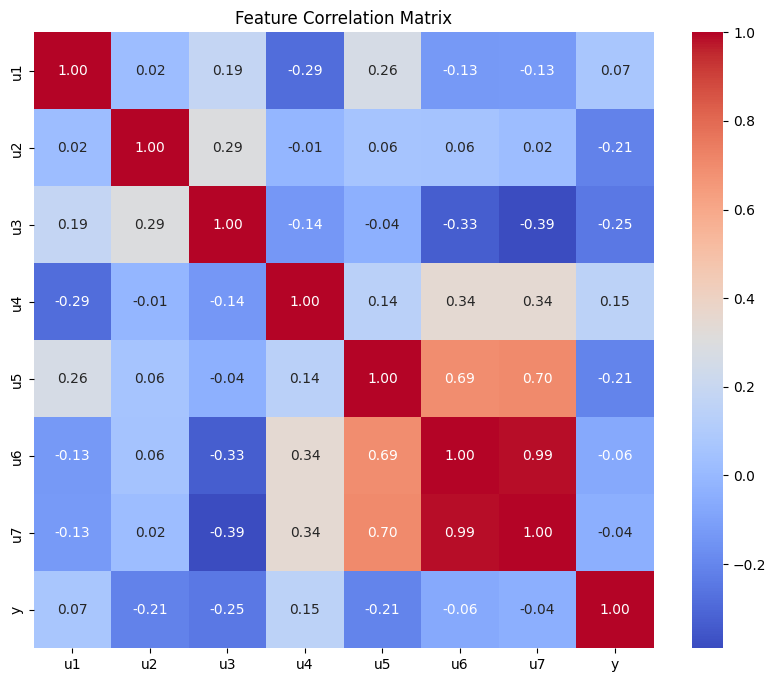

In [8]:
# Define Target Variable
target_col = 'y'

# %% [markdown]
# ## Step 2: Feature Selection (Correlation Method)
# Identifying relevant inputs based on correlation with the target.

# %%
# Calculate Correlation Matrix
correlation_matrix = df.corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# Select features with correlation > threshold (e.g., 0.1)
threshold = 0.05  # Adjusted to ensure we keep enough features
cor_target = abs(correlation_matrix[target_col])
relevant_features = cor_target[cor_target > threshold].index.tolist()

# Remove target itself from features
if target_col in relevant_features:
    relevant_features.remove(target_col)

print(f"Selected Features based on correlation: {relevant_features}")

Selected Features based on correlation: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']


In [10]:
# Prepare X and y
X = df[relevant_features].values
y = df[target_col].values

# %% [markdown]
# ## Step 3: Global Model Building (Parametric)
# ### 3.0: Data Splitting and Scaling
# 70% Training, 30% Testing.

# %%
# Split Data (Shuffle=False is standard for time-series/process data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=42)

In [11]:
# Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

print(f"Training shapes: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Testing shapes: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

# Dictionary to store results
results = {}

Training shapes: X=(1675, 6), y=(1675, 1)
Testing shapes: X=(719, 6), y=(719, 1)


In [12]:
# Helper function to build FFNN
def build_fnn(input_dim, hidden_layers=[32], learning_rate=0.01, reg_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for neurons in hidden_layers:
        model.add(Dense(neurons, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(reg_rate)))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model


In [14]:
# Helper function to train and evaluate
def train_evaluate(model, X_tr, y_tr, X_te, y_te, model_name, epochs=50):
    print(f"Training {model_name}...")
    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=32, verbose=0, validation_split=0.1)

    # Predict
    y_pred_scaled = model.predict(X_te, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_te)

    # Metrics
    sse = np.sum((y_true - y_pred)**2)
    r2 = r2_score(y_true, y_pred)

    results[model_name] = {
        'y_pred': y_pred,
        'y_true': y_true,
        'sse': sse,
        'r2': r2,
        'history': history
    }
    print(f"{model_name} -> SSE: {sse:.4f}, R2: {r2:.4f}")


In [15]:
# %% [markdown]
# ### 3.1: Shallow vs. Deep Neural Networks

# %%
# Shallow NN (Single Hidden Layer)
model_shallow = build_fnn(input_dim=X_train_scaled.shape[1], hidden_layers=[10])
train_evaluate(model_shallow, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, "Shallow NN")

# Deep NN (Multiple Hidden Layers)
model_deep = build_fnn(input_dim=X_train_scaled.shape[1], hidden_layers=[64, 32, 16])
train_evaluate(model_deep, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, "Deep NN")

# %% [markdown]
# ### 3.2: Hyperparameter Tuning
# Grid search for Learning Rates, Regularization, and Hidden Layers.

# %%
learning_rates = [0.01, 0.001]
regularizers = [0.0, 0.001]
layer_configs = [[16], [32, 16], [64, 32, 16]]

best_sse = float('inf')
best_config = ""

print("Starting Hyperparameter Tuning...")
for lr in learning_rates:
    for reg in regularizers:
        for layers in layer_configs:
            config_name = f"LR={lr}_Reg={reg}_L={layers}"
            # Train smaller epochs for tuning speed
            temp_model = build_fnn(X_train_scaled.shape[1], layers, lr, reg)
            temp_model.fit(X_train_scaled, y_train_scaled, epochs=20, verbose=0, batch_size=32)

            # Evaluate
            pred_s = temp_model.predict(X_test_scaled, verbose=0)
            pred = scaler_y.inverse_transform(pred_s)
            true = scaler_y.inverse_transform(y_test_scaled)
            sse = np.sum((true - pred)**2)

            if sse < best_sse:
                best_sse = sse
                best_config = config_name

print(f"Best Configuration: {best_config} with SSE: {best_sse:.4f}")

Training Shallow NN...
Shallow NN -> SSE: 21.1300, R2: 0.0875
Training Deep NN...
Deep NN -> SSE: 21.3065, R2: 0.0799
Starting Hyperparameter Tuning...
Best Configuration: LR=0.01_Reg=0.001_L=[16] with SSE: 16.6453


In [16]:
# %% [markdown]
# ### 3.3: Autoregressive Deep NN Model
# Including lagged output variables y(t-1), y(t-2) as inputs.

# %%
# Create lagged features
df_ar = df.copy()
lags = 2
for i in range(1, lags + 1):
    df_ar[f'y_lag_{i}'] = df_ar[target_col].shift(i)

# Drop NaN values created by shifting
df_ar.dropna(inplace=True)

# Update features list
features_ar = relevant_features + [f'y_lag_{i}' for i in range(1, lags + 1)]
print(f"AR Model Features: {features_ar}")

X_ar = df_ar[features_ar].values
y_ar = df_ar[target_col].values

# Split AR Data
X_tr_ar, X_te_ar, y_tr_ar, y_te_ar = train_test_split(X_ar, y_ar, test_size=0.3, shuffle=False)

# Scale AR Data
scaler_X_ar = StandardScaler()
X_tr_ar_s = scaler_X_ar.fit_transform(X_tr_ar)
X_te_ar_s = scaler_X_ar.transform(X_te_ar)

scaler_y_ar = StandardScaler()
y_tr_ar_s = scaler_y_ar.fit_transform(y_tr_ar.reshape(-1, 1))
y_te_ar_s = scaler_y_ar.transform(y_te_ar.reshape(-1, 1))

# Train AR Model
model_ar = build_fnn(input_dim=X_tr_ar_s.shape[1], hidden_layers=[32, 16])
train_evaluate(model_ar, X_tr_ar_s, y_tr_ar_s, X_te_ar_s, y_te_ar_s, "Autoregressive NN")


AR Model Features: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'y_lag_1', 'y_lag_2']
Training Autoregressive NN...
Autoregressive NN -> SSE: 0.7328, R2: 0.9683


In [17]:
# %% [markdown]
# ### 3.4: LSTM Model
# Reshaping data for Long Short-Term Memory networks.

# %%
# Reshape for LSTM: [samples, time_steps, features]
# We treat the input vector as a single time step with multiple features

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

def build_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(50, activation='tanh'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

print("Training LSTM Model...")
model_lstm = build_lstm((1, X_train_scaled.shape[1]))
history_lstm = model_lstm.fit(X_train_lstm, y_train_scaled, epochs=50, batch_size=32, verbose=0)

y_pred_lstm_s = model_lstm.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_s)
y_true_lstm = scaler_y.inverse_transform(y_test_scaled)

sse_lstm = np.sum((y_true_lstm - y_pred_lstm)**2)
r2_lstm = r2_score(y_true_lstm, y_pred_lstm)

results['LSTM'] = {'y_pred': y_pred_lstm, 'y_true': y_true_lstm, 'sse': sse_lstm, 'r2': r2_lstm}
print(f"LSTM -> SSE: {sse_lstm:.4f}, R2: {r2_lstm:.4f}")


Training LSTM Model...
LSTM -> SSE: 28.0614, R2: -0.2118


In [18]:
# %% [markdown]
# ## Step 4: Non-Parametric JIT Learning
# Just-In-Time Learning using k-NN and Local Neural Networks.
# *Note: This process loops through every test point and trains a new model. It can be slow.*

# %%
k = 30  # Number of neighbors
JIT_predictions = []

print(f"Starting JIT Learning on {len(X_test_scaled)} test points...")
print("This may take a few minutes. Using tqdm for progress tracking.")

# 1. Fit Nearest Neighbors on Training Data
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(X_train_scaled)

# 2. Iterate through Validation/Test Data
for i in tqdm(range(len(X_test_scaled))):
    # Current query point
    query_point = X_test_scaled[i].reshape(1, -1)

    # Find neighbors
    distances, indices = nbrs.kneighbors(query_point)
    indices = indices[0]

    # Retrieve local dataset
    X_local = X_train_scaled[indices]
    y_local = y_train_scaled[indices]

    # Build Local Model (Small & Fast)
    # Using specific random seed in loop to ensure stability if needed, or rely on global seed
    local_model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(10, activation='relu'),
        Dense(1, activation='linear')
    ])
    local_model.compile(optimizer='adam', loss='mse')

    # Train Local Model (Few epochs to save time)
    local_model.fit(X_local, y_local, epochs=15, verbose=0, batch_size=k)

    # Predict
    pred_s = local_model.predict(query_point, verbose=0)
    JIT_predictions.append(pred_s[0][0])

    # Clear session occasionally to prevent memory leaks in very long loops
    if i % 100 == 0:
        keras.backend.clear_session()

# Transform predictions back to original scale
JIT_predictions = np.array(JIT_predictions).reshape(-1, 1)
y_pred_jit = scaler_y.inverse_transform(JIT_predictions)
y_true_jit = scaler_y.inverse_transform(y_test_scaled)

sse_jit = np.sum((y_true_jit - y_pred_jit)**2)
r2_jit = r2_score(y_true_jit, y_pred_jit)

results['JIT Learning'] = {'y_pred': y_pred_jit, 'y_true': y_true_jit, 'sse': sse_jit, 'r2': r2_jit}
print(f"JIT Learning -> SSE: {sse_jit:.4f}, R2: {r2_jit:.4f}")

Starting JIT Learning on 719 test points...
This may take a few minutes. Using tqdm for progress tracking.


100%|██████████| 719/719 [19:58<00:00,  1.67s/it]

JIT Learning -> SSE: 30.9204, R2: -0.3353



=== Final Model Comparison ===
               Model        SSE        R2
0         Shallow NN  21.130025  0.087520
1            Deep NN  21.306452  0.079901
2  Autoregressive NN   0.732830  0.968332
3               LSTM  28.061412 -0.211805
4       JIT Learning  30.920408 -0.335268


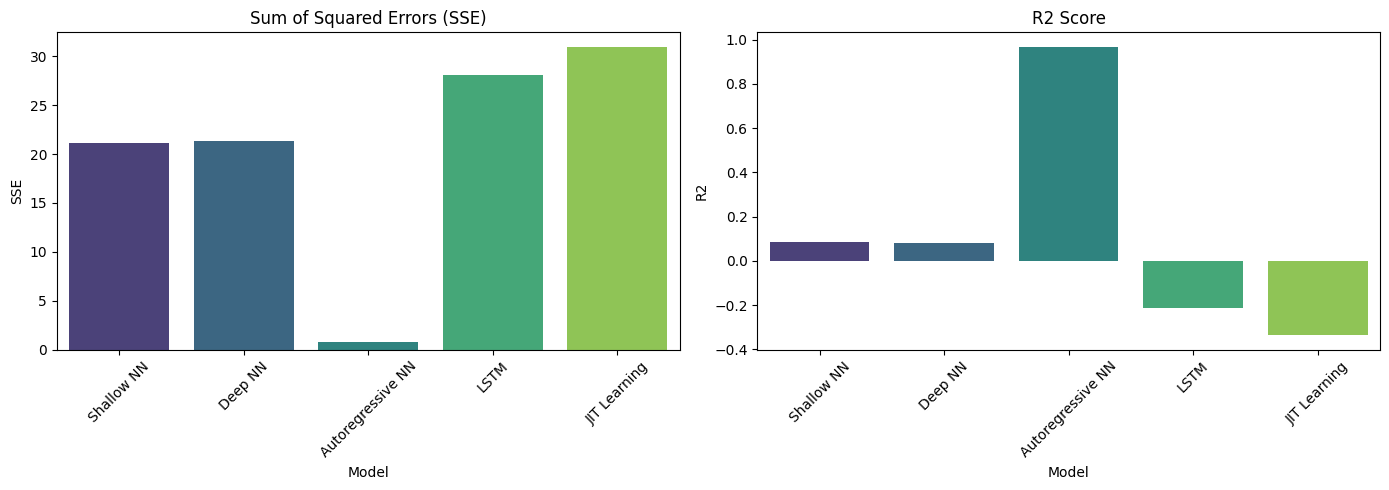

In [19]:
# %% [markdown]
# ## Step 5: Presentation of Results
# Metrics, Residual Plots, Autocorrelation, and Predictions.

# %%
# 1. Metrics Comparison Table
metrics_data = []
for name, res in results.items():
    metrics_data.append({
        'Model': name,
        'SSE': res['sse'],
        'R2': res['r2']
    })

metrics_df = pd.DataFrame(metrics_data)
print("\n=== Final Model Comparison ===")
print(metrics_df)

# Plot SSE and R2
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='Model', y='SSE', data=metrics_df, ax=ax[0], palette='viridis')
ax[0].set_title('Sum of Squared Errors (SSE)')
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Model', y='R2', data=metrics_df, ax=ax[1], palette='viridis')
ax[1].set_title('R2 Score')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

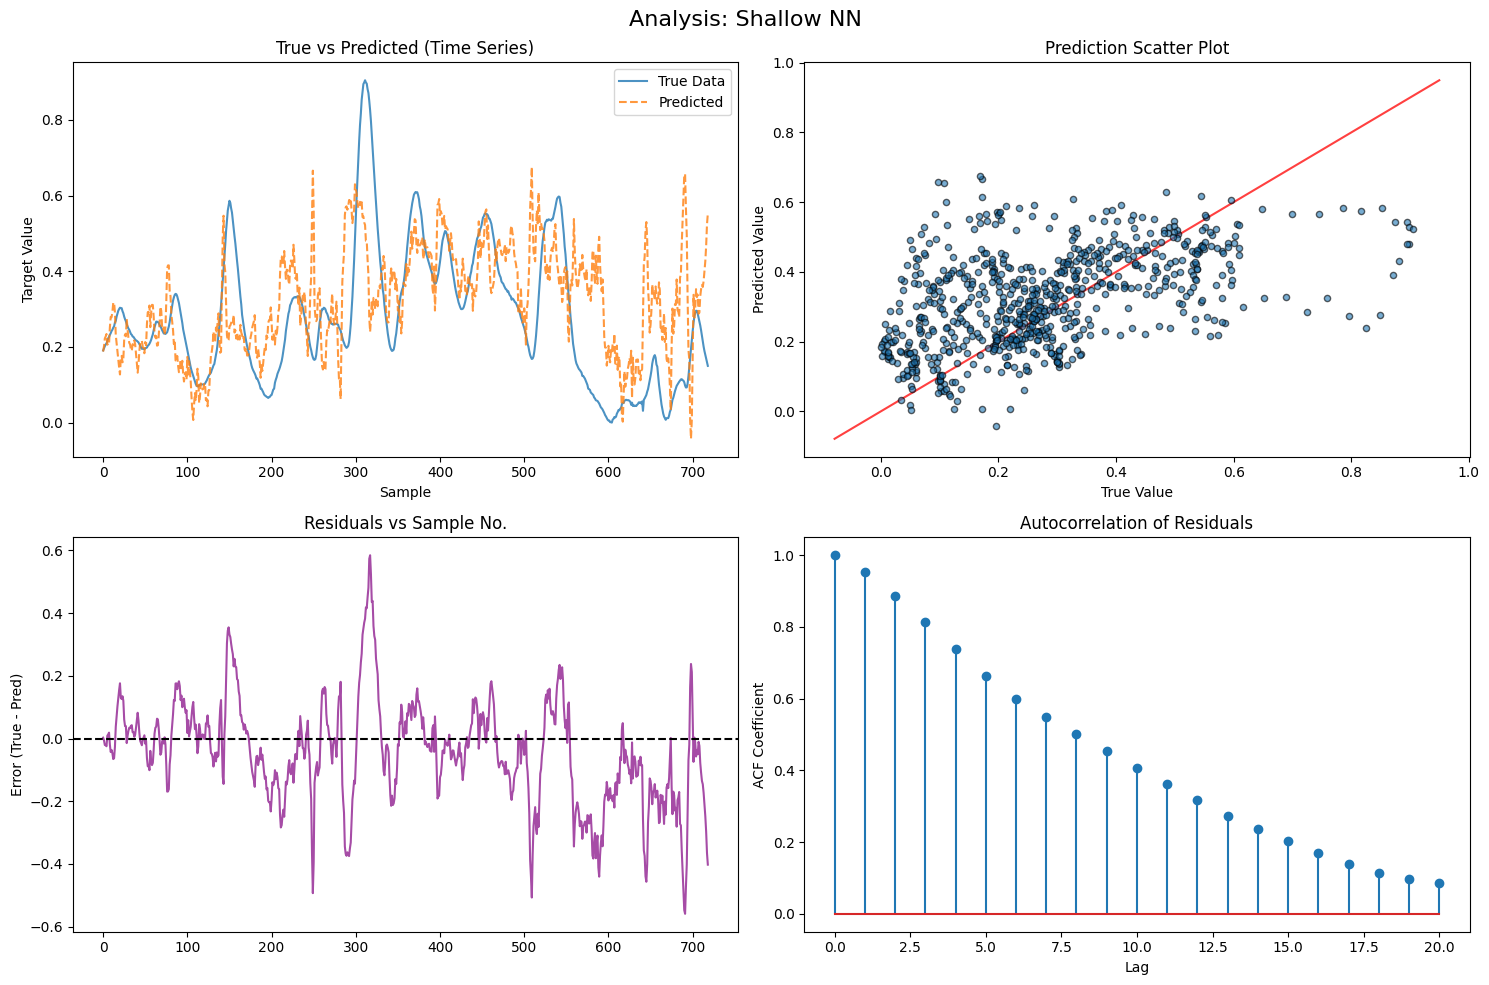

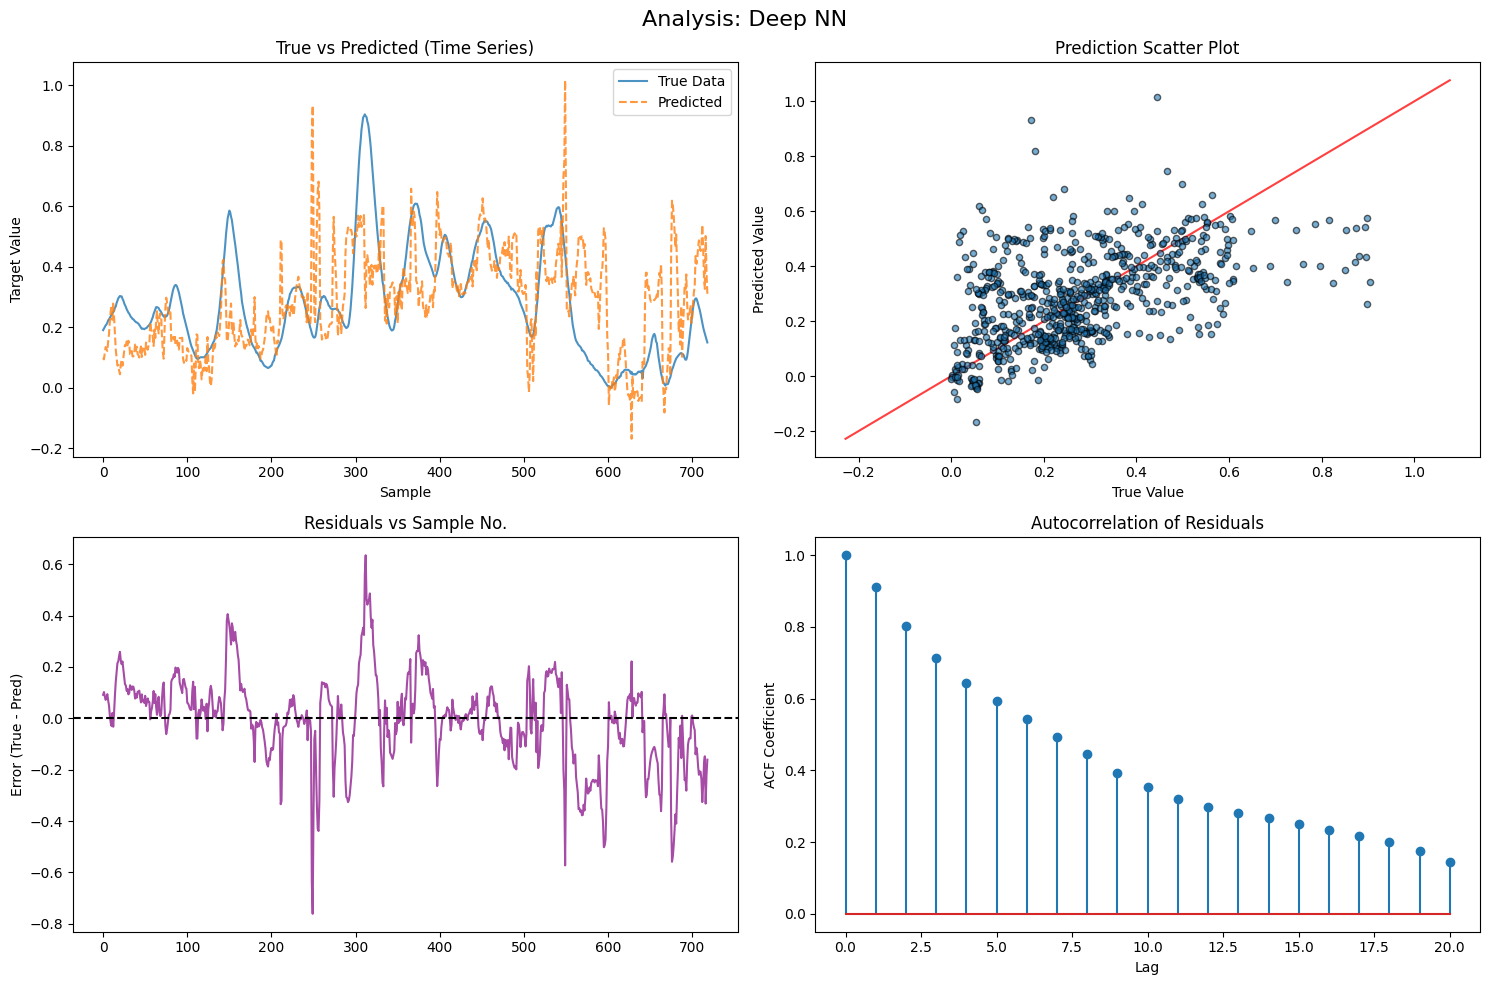

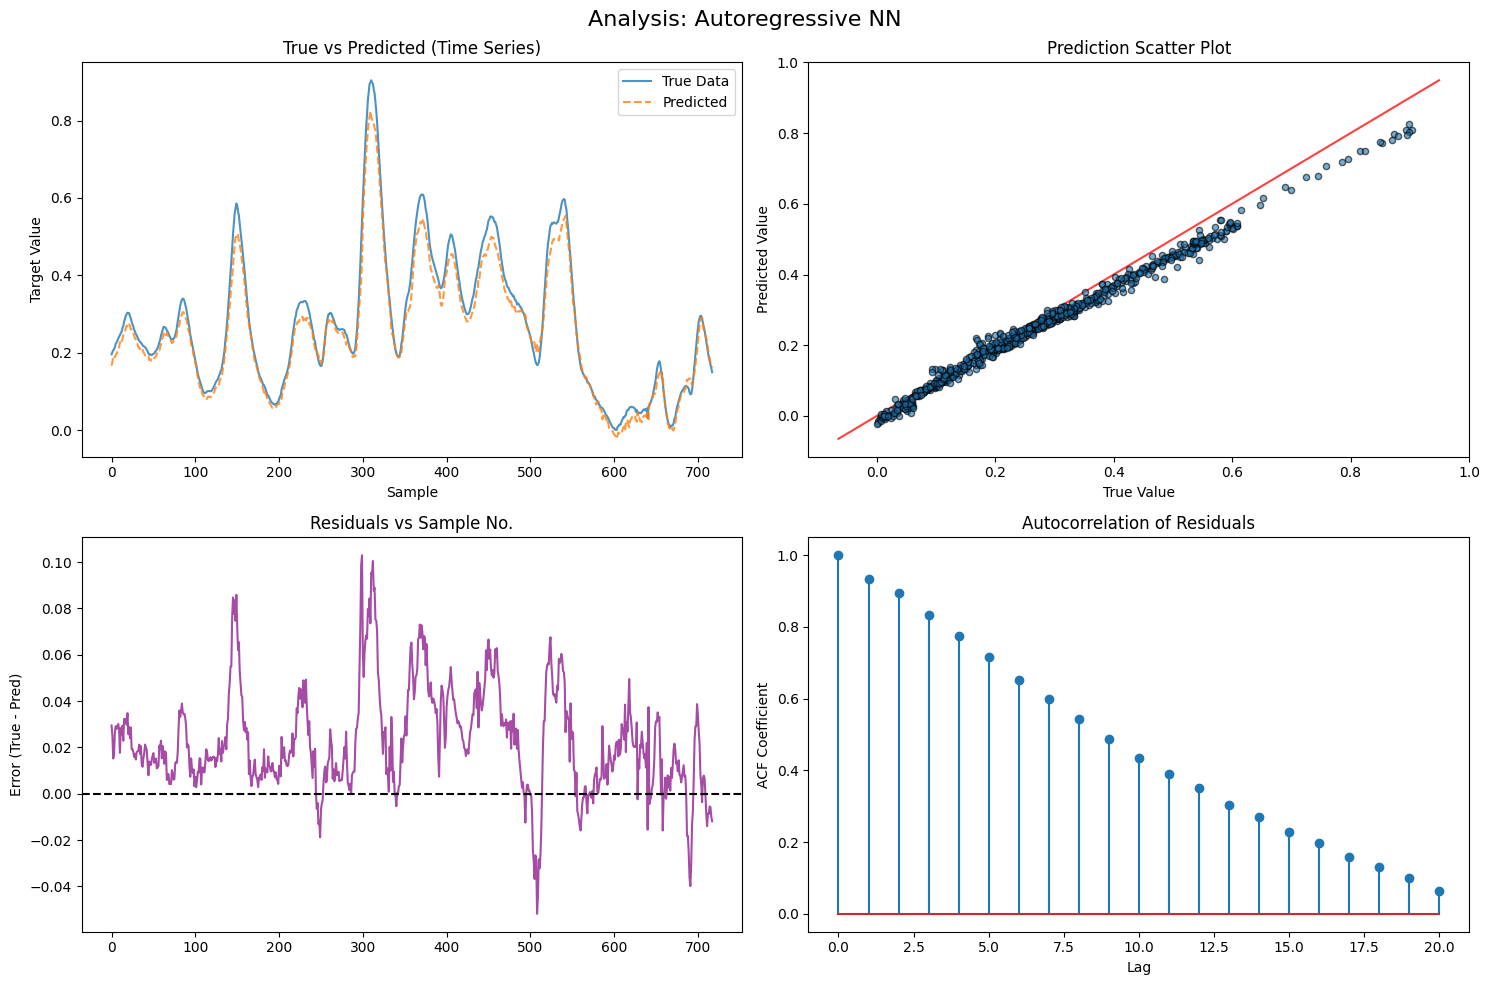

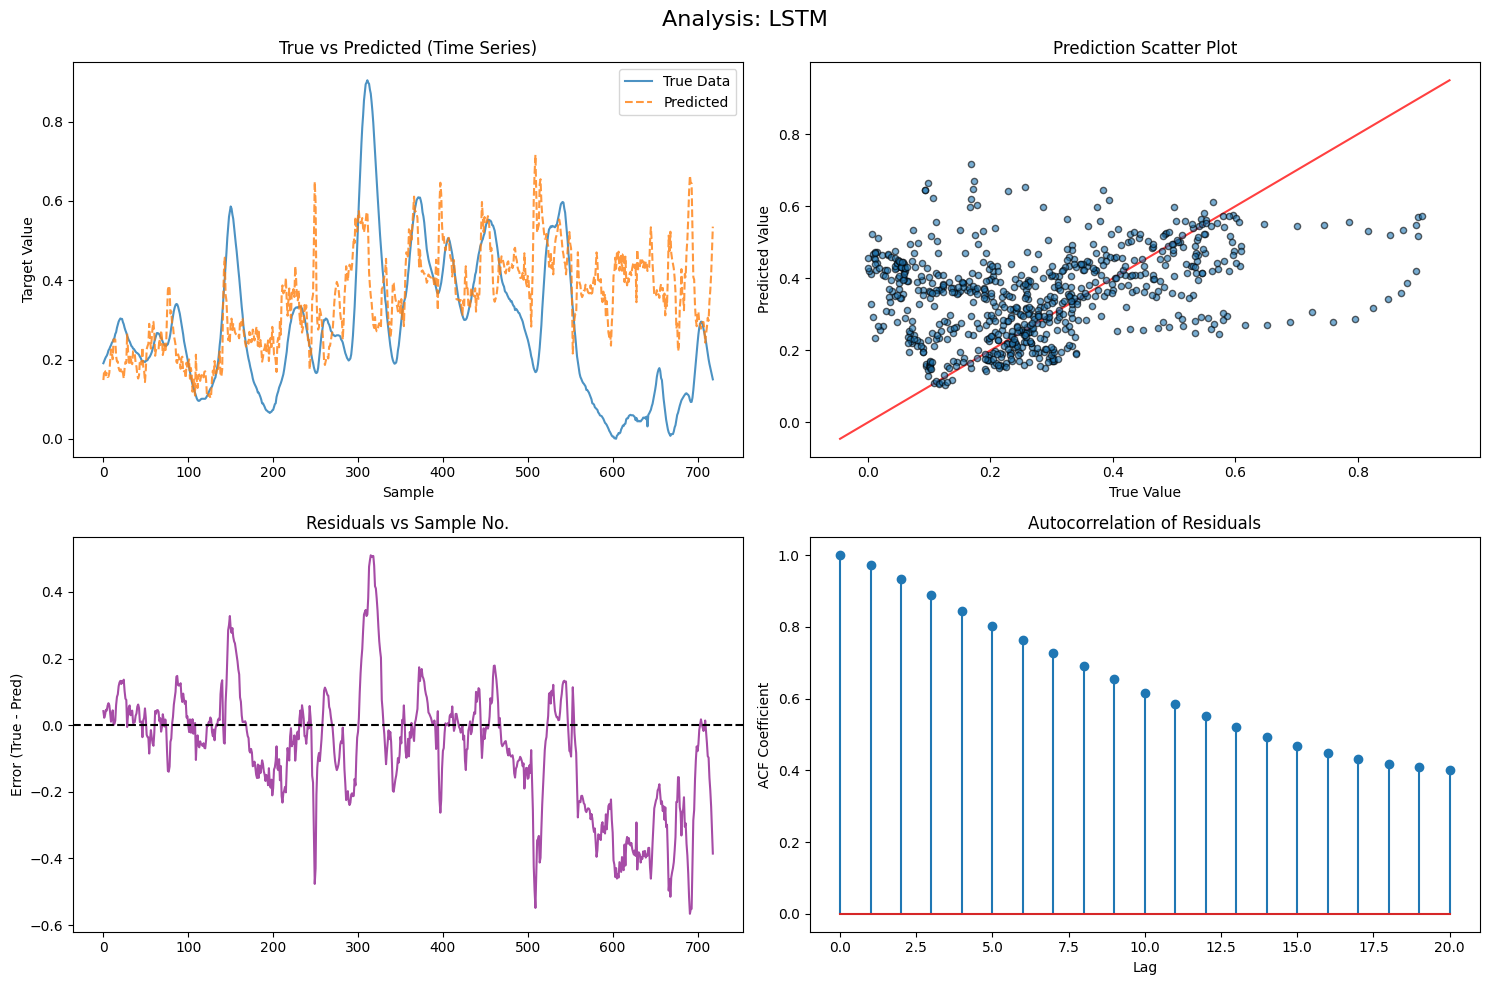

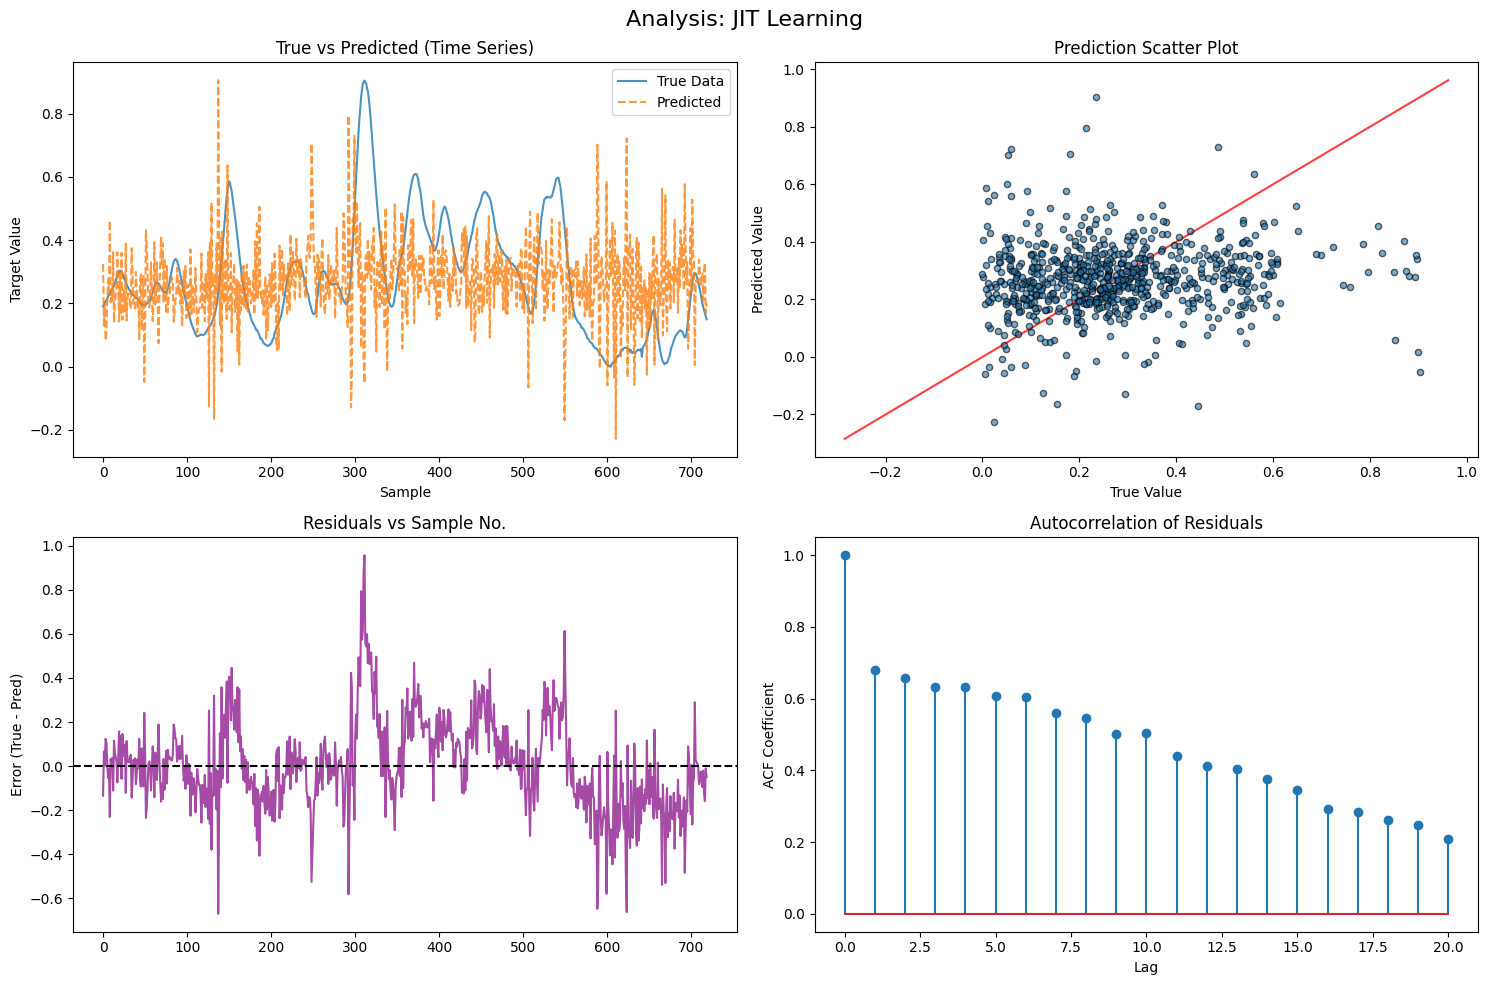

In [21]:
# %% [markdown]
# ### Residual Analysis & Plots

# %%
def plot_model_analysis(model_name):
    if model_name not in results:
        return

    data = results[model_name]
    y_p = data['y_pred']
    y_t = data['y_true']

    # Align lengths if necessary (AR model might differ slightly due to lags)
    min_len = min(len(y_p), len(y_t))
    y_p = y_p[:min_len]
    y_t = y_t[:min_len]

    residuals = y_t - y_p

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Analysis: {model_name}", fontsize=16)

    # 1. Time Series Comparison
    axs[0, 0].plot(y_t, label='True Data', alpha=0.8)
    axs[0, 0].plot(y_p, label='Predicted', alpha=0.8, linestyle='--')
    axs[0, 0].set_title("True vs Predicted (Time Series)")
    axs[0, 0].set_xlabel("Sample")
    axs[0, 0].set_ylabel("Target Value")
    axs[0, 0].legend()

    # 2. Scatter Plot
    axs[0, 1].scatter(y_t, y_p, alpha=0.6, edgecolors='k', s=20)
    # Perfect fit line
    lims = [np.min([axs[0, 1].get_xlim(), axs[0, 1].get_ylim()]),
            np.max([axs[0, 1].get_xlim(), axs[0, 1].get_ylim()])]
    axs[0, 1].plot(lims, lims, 'r-', alpha=0.75, zorder=0)
    axs[0, 1].set_title("Prediction Scatter Plot")
    axs[0, 1].set_xlabel("True Value")
    axs[0, 1].set_ylabel("Predicted Value")

    # 3. Residuals vs Samples
    axs[1, 0].plot(residuals, color='purple', alpha=0.7)
    axs[1, 0].axhline(0, color='black', linestyle='--')
    axs[1, 0].set_title("Residuals vs Sample No.")
    axs[1, 0].set_ylabel("Error (True - Pred)")

    # 4. Autocorrelation of Residuals
    # Using statsmodels acf
    acf_vals = acf(residuals, nlags=20, fft=True)
    axs[1, 1].stem(range(len(acf_vals)), acf_vals)
    axs[1, 1].set_title("Autocorrelation of Residuals")
    axs[1, 1].set_xlabel("Lag")
    axs[1, 1].set_ylabel("ACF Coefficient")

    plt.tight_layout()
    plt.show()

# Generate plots for all models
for model_name in results.keys():
    plot_model_analysis(model_name)